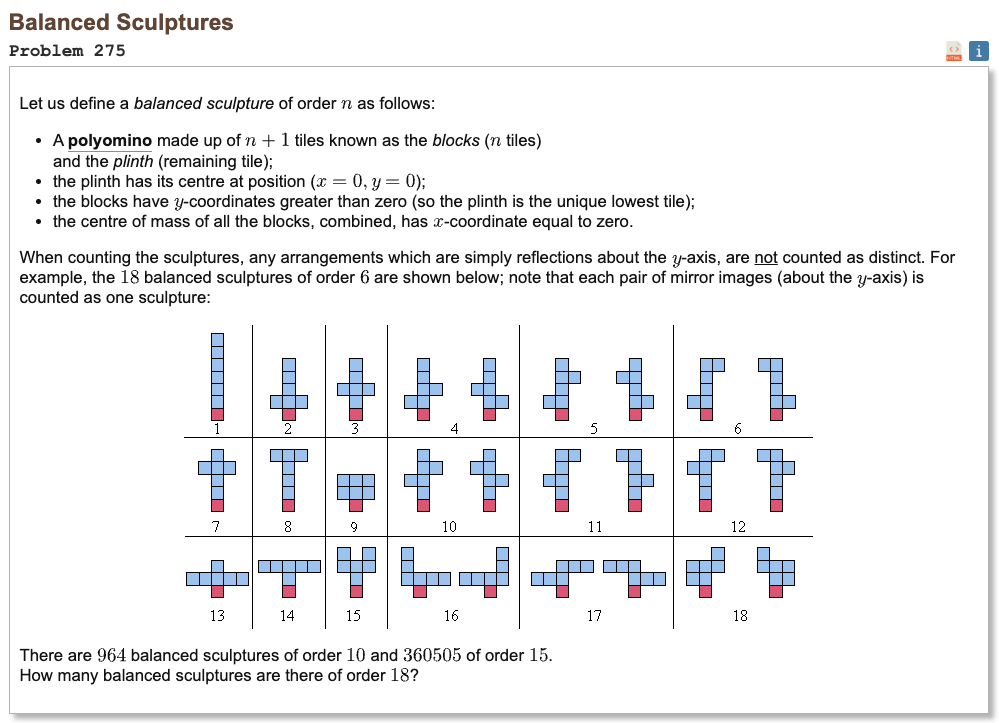

## Initial approach

* the key simplification is that the block directly above the plinth must always exist, so you can treat that block as the root and shift the whole problem up by one level
* after that shift, you only need to build connected polyominoes with y at least 0, and the balance condition becomes very simple: the sum of all x coordinates must be 0
* count all valid rooted shapes first, even if a shape and its mirror image are both included separately
* then count only the shapes that are already symmetric around the y axis
* once you have those two counts, the final number is (total + symmetric) // 2, because mirror pairs merge into one while symmetric ones stay single
* a Redelmeier style search works well here because it grows shapes one cell at a time without generating the same connected shape again and again
* a small pruning rule helps a lot: if the current x balance is already too far from 0 to be fixed by the remaining cells, stop that branch early
* the final answer for order 18 is 15030564, and the problem statement also gives the checkpoints 18 for order 6, 964 for order 10, and 360505 for order 15

In [1]:
def count_total_balanced(n):
    x_max = n - 1
    y_max = n - 1
    width = 2 * x_max + 1
    shift = x_max
    grid = width * (y_max + 1)

    x_of = [0] * grid
    for y in range(y_max + 1):
        base = y * width
        for xi in range(width):
            x_of[base + xi] = xi - shift

    neighbors = [[] for _ in range(grid)]
    for y in range(y_max + 1):
        row = y * width
        for xi in range(width):
            idx = row + xi
            if xi > 0:
                neighbors[idx].append(idx - 1)
            if xi < width - 1:
                neighbors[idx].append(idx + 1)
            if y > 0:
                neighbors[idx].append(idx - width)
            if y < y_max:
                neighbors[idx].append(idx + width)

    root = shift
    seen = bytearray(grid)
    queue = [0] * (8 * n + 50)

    seen[root] = 1
    q_end = 0
    for nb in neighbors[root]:
        if seen[nb] == 0:
            seen[nb] = 1
            queue[q_end] = nb
            q_end += 1

    ans = 0

    def rec(q_begin, q_end_now, size, moment, min_x, max_x):
        nonlocal ans

        if size == n:
            if moment == 0:
                ans += 1
            return

        remaining = n - size
        min_possible_x = min_x - remaining
        max_possible_x = max_x + remaining

        if moment + remaining * min_possible_x > 0:
            return
        if moment + remaining * max_possible_x < 0:
            return

        for i in range(q_begin, q_end_now):
            cell = queue[i]
            x = x_of[cell]
            added = 0

            for nb in neighbors[cell]:
                if seen[nb] == 0:
                    seen[nb] = 1
                    queue[q_end_now + added] = nb
                    added += 1

            next_min_x = x if x < min_x else min_x
            next_max_x = x if x > max_x else max_x

            rec(i + 1, q_end_now + added, size + 1, moment + x, next_min_x, next_max_x)

            for j in range(q_end_now, q_end_now + added):
                seen[queue[j]] = 0

    rec(0, q_end, 1, 0, 0, 0)
    return ans


def count_symmetric(n):
    x_max = n - 1
    y_max = n - 1
    width = 2 * x_max + 1
    shift = x_max
    grid = width * (y_max + 1)

    x_of = [0] * grid
    for y in range(y_max + 1):
        base = y * width
        for xi in range(width):
            x_of[base + xi] = xi - shift

    neighbors = [[] for _ in range(grid)]
    for y in range(y_max + 1):
        row = y * width
        for xi in range(width):
            idx = row + xi
            x = xi - shift
            if x < 0:
                continue
            if xi > shift:
                neighbors[idx].append(idx - 1)
            if xi < width - 1:
                neighbors[idx].append(idx + 1)
            if y > 0:
                neighbors[idx].append(idx - width)
            if y < y_max:
                neighbors[idx].append(idx + width)

    root = shift
    seen = bytearray(grid)
    queue = [0] * (8 * n + 50)

    seen[root] = 1
    q_end = 0
    for nb in neighbors[root]:
        if seen[nb] == 0:
            seen[nb] = 1
            queue[q_end] = nb
            q_end += 1

    ans = 0

    def rec(q_begin, q_end_now, full_size):
        nonlocal ans

        if full_size == n:
            ans += 1
            return

        for i in range(q_begin, q_end_now):
            cell = queue[i]
            x = x_of[cell]
            add = 1 if x == 0 else 2
            new_full_size = full_size + add

            if new_full_size > n:
                continue

            added = 0
            for nb in neighbors[cell]:
                if seen[nb] == 0:
                    seen[nb] = 1
                    queue[q_end_now + added] = nb
                    added += 1

            rec(i + 1, q_end_now + added, new_full_size)

            for j in range(q_end_now, q_end_now + added):
                seen[queue[j]] = 0

    rec(0, q_end, 1)
    return ans


def balanced_sculptures(n):
    total = count_total_balanced(n)
    symmetric = count_symmetric(n)
    return (total + symmetric) // 2

In [2]:
%%time
assert balanced_sculptures(6) == 18
assert balanced_sculptures(10) == 964
assert balanced_sculptures(15) == 360505

result = balanced_sculptures(18)
print("Result:", result)

Result: 15030564
CPU times: user 3min 59s, sys: 1.13 s, total: 4min 1s
Wall time: 4min 3s
